# Idealized corner cases: masks and boundaries on tripolar and lat-lon-cap grids

`regionate` snaps geographic regions to a discrete ocean-model grid in two directions:

- **mask &rarr; boundary** (`grid_boundaries_from_mask` / `MaskRegions`): given a boolean cell
  mask, trace the staggered cell-corner **boundary loop(s)** that enclose it;
- **boundary &rarr; mask** (`GriddedRegion(name, lons, lats, grid)`): given a lon/lat polygon,
  rasterize it to the boolean cell **mask** it encloses.

This notebook exercises both directions on a set of deliberately *awkward* idealized regions,
**side by side on two very different grids**:

- **MOM6** &mdash; a global **tripolar, single-tile** grid: periodic in *X* with a bipolar
  north **fold**;
- **ECCOv4 LLC90** &mdash; a **lat-lon-cap, multi-tile** grid: 13 faces stitched by
  `face_connections`.

Because the tracer follows each grid's own topology, a region wrapping *any* seam &mdash; the
periodic-*X* seam, the fold, or a tile seam &mdash; is stitched into one seam-consistent
boundary rather than split into pieces.

The masks below are built from **pure geographic predicates** (no land mask), so the figures
show the raw grid-conforming geometry rather than coastlines. In each figure: **grey dots** are
masked cells and **coloured lines** are the traced discrete boundary loops (one colour per
loop).

In [1]:
%matplotlib inline
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

from load_example_model_grid import load_MOM6_zint_heat_budget
from load_example_ECCO_grid import load_ECCO_LLC90_grid
from regionate.boundaries import grid_boundaries_from_mask
from regionate import GriddedRegion

# MOM6 needs its bipolar fold declared (fold=True) so Arctic regions stitch across the seam;
# ECCO carries its tile topology via face_connections.
gM = load_MOM6_zint_heat_budget(fold=True)
gE = load_ECCO_LLC90_grid(data_dir="../data")
GRIDS = [("MOM6 (tripolar, single-tile)", gM),
         ("ECCOv4 LLC90 (lat-lon-cap, multi-tile)", gE)]

File 'MOM6_global_example_vertically_integrated_heat_budget_v0_0_6.nc' already exists at ../data/MOM6_global_example_vertically_integrated_heat_budget_v0_0_6.nc. Skipping download.


File 'GRID_GEOMETRY_ECCO_V4r4_native_llc0090.nc' already exists at ../data/GRID_GEOMETRY_ECCO_V4r4_native_llc0090.nc. Skipping download.


/Users/henrifdrake/anaconda3/envs/regionate-pr22/lib/python3.13/site-packages/xgcm/grid.py:477: UserWarning: The north-fold (tripolar) boundary condition is experimental. Its API and numerical behavior may change in future releases, and it has not yet been validated across the full range of grid configurations. Please review results carefully and report any issues at https://github.com/xgcm/xgcm/issues.
  warnings.warn(


In [2]:
def nlon(a):
    "Normalize longitude to [-180, 180) (the two grids use different lon conventions)."
    return ((np.asarray(a) + 180.) % 360.) - 180.

def build_mask(grid, pred):
    "Boolean cell mask from a geographic predicate pred(lon[-180,180), lat)."
    lon = nlon(grid._ds.geolon.values); lat = grid._ds.geolat.values
    return xr.DataArray(pred(lon, lat), dims=grid._ds.geolon.dims, coords=grid._ds.geolon.coords)

def loops(grid, mask):
    "Traced boundary loops as (lons, lats), sorted outer->inner for consistent colouring."
    _, _, _, lon_l, lat_l = grid_boundaries_from_mask(grid, mask)
    lp = list(zip(lon_l, lat_l))
    lp.sort(key=lambda p: (-len(p[0]), -float(np.mean(p[1]))))
    return lp

def draw_loop(ax, lons, lats, color):
    "Draw one boundary loop, breaking the line where it jumps across the antimeridian."
    lons = nlon(lons); lats = np.asarray(lats)
    xs, ys = [lons[0]], [lats[0]]
    for k in range(1, len(lons)):
        if abs(lons[k] - lons[k - 1]) > 180.:
            ax.plot(xs, ys, "-", color=color, lw=1.6, transform=ccrs.PlateCarree(), zorder=5)
            xs, ys = [], []
        xs.append(lons[k]); ys.append(lats[k])
    ax.plot(xs, ys, "-", color=color, lw=1.6, transform=ccrs.PlateCarree(), zorder=5)

def _basemap(fig, col, proj, extent):
    ax = fig.add_subplot(1, 2, col + 1, projection=proj)
    ax.set_global() if extent is None else ax.set_extent(extent, ccrs.PlateCarree())
    ax.coastlines(resolution="110m", color="0.6", lw=0.5)
    ax.gridlines(color="0.85", lw=0.4)
    return ax

def plot_case(pred, proj, title, extent=None):
    "mask -> boundary, side by side on both grids."
    fig = plt.figure(figsize=(12, 5.6))
    for col, (name, grid) in enumerate(GRIDS):
        ax = _basemap(fig, col, proj, extent)
        mask = build_mask(grid, pred)
        lon = nlon(grid._ds.geolon.values).ravel(); lat = grid._ds.geolat.values.ravel()
        m = mask.values.ravel()
        ax.scatter(lon[m], lat[m], s=2, c="0.5", alpha=0.35, transform=ccrs.PlateCarree(), zorder=2)
        lps = loops(grid, mask)
        for n, (lo, la) in enumerate(lps):
            draw_loop(ax, lo, la, f"C{n % 10}")
        ax.set_title(f"{name}\n{int(mask.sum())} cells, {len(lps)} boundary loop(s)", fontsize=9)
    fig.suptitle(title, fontsize=12); fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

def plot_b2m(lons, lats, proj, title, extent=None):
    "boundary -> mask: rasterize a lon/lat polygon (black), then re-trace it (red)."
    fig = plt.figure(figsize=(12, 5.6))
    for col, (name, grid) in enumerate(GRIDS):
        ax = _basemap(fig, col, proj, extent)
        try:
            reg = GriddedRegion("case", np.asarray(lons), np.asarray(lats), grid)
        except Exception:
            draw_loop(ax, np.append(lons, lons[0]), np.append(lats, lats[0]), "k")
            ax.set_title(f"{name}\nboundary->mask needs a 1D/2D grid", fontsize=9)
            ax.text(0.5, 0.5, "polygon rasterization (regionmask) needs a 1D/2D grid.\n"
                    "On a multi-tile grid, build the mask per tile\n"
                    "(e.g. load_example_ECCO_grid.atlantic_basin_mask),\nthen trace it (mask->boundary).",
                    transform=ax.transAxes, ha="center", va="center", fontsize=8, color="0.3")
            continue
        lon = nlon(grid._ds.geolon.values).ravel(); lat = grid._ds.geolat.values.ravel()
        m = reg.mask.values.ravel()
        ax.scatter(lon[m], lat[m], s=2, c="0.5", alpha=0.35, transform=ccrs.PlateCarree(), zorder=2)
        draw_loop(ax, np.append(lons, lons[0]), np.append(lats, lats[0]), "k")   # input polygon
        for lo, la in loops(grid, reg.mask):                                      # re-traced boundary
            draw_loop(ax, lo, la, "C3")
        ax.set_title(f"{name}\n{int(reg.mask.sum())} cells enclosed", fontsize=9)
    fig.suptitle(title + "   (black = input polygon, red = re-traced boundary)", fontsize=11)
    fig.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

def box(lomin, lomax, lamin, lamax):
    return lambda lon, lat: (lon >= lomin) & (lon <= lomax) & (lat >= lamin) & (lat <= lamax)

def nested(lon0, lat0):
    "Concentric boxes: land ring (outer) with an inland sea holding an island holding a lake."
    def r(lon, lat, s): return (np.abs(lon - lon0) < s) & (np.abs(lat - lat0) < s)
    return lambda lon, lat: ((r(lon, lat, 24) & ~r(lon, lat, 17)) | (r(lon, lat, 10) & ~r(lon, lat, 4)))

## Part 1 &mdash; mask &rarr; boundary

### 1. A compact mask containing the **North Pole**

The Arctic is inside the ocean domain on both grids, so a polar cap (`lat > 75`) is one filled
disk with a **single** boundary loop &mdash; even though it straddles MOM6's bipolar fold and
ECCO's Arctic tile cap. The tracer stitches across those seams.

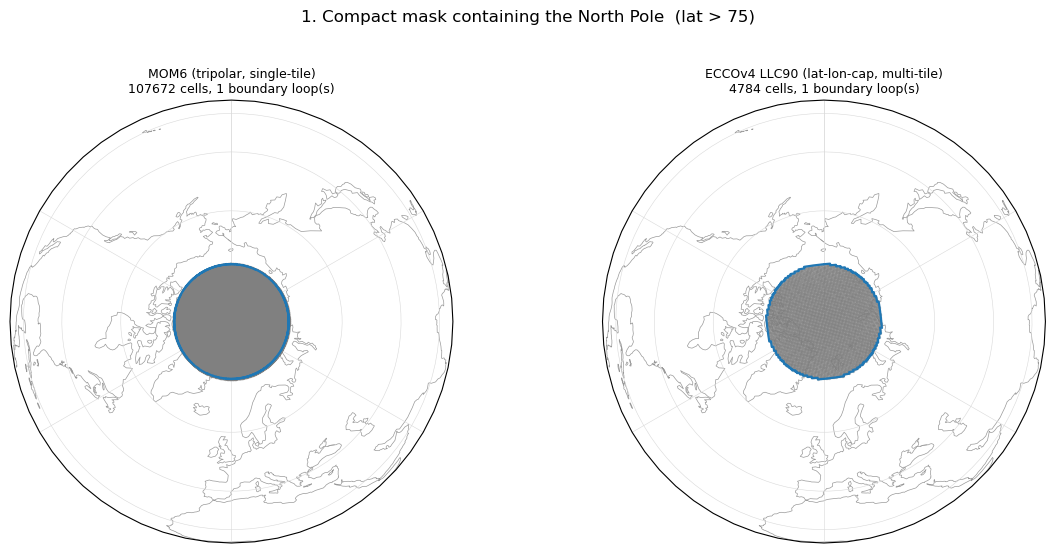

In [3]:
plot_case(lambda lo, la: la > 75., ccrs.Orthographic(0, 90),
          "1. Compact mask containing the North Pole  (lat > 75)")

### 2. A compact mask reaching toward the **South Pole**

The two grids end differently in the far south, and the traced boundary shows it. The MOM6
grid genuinely stops short of the pole (its southernmost row is at about &minus;81.7&deg;),
so a southern cap (`lat < -70`) is really an **annulus** &mdash; a band between
&minus;70&deg; and the grid's open southern edge &mdash; and returns **two** boundary loops.
ECCO's LLC90 grid, by contrast, reaches all the way to &minus;90&deg;: its southern
"boundary" is a *fold* of the grid onto itself (segments of the tile-0/3 corner rows and the
lon&nbsp;&asymp;&nbsp;&minus;115&deg; cut, all under the Antarctic ice sheet). regionate
recognises the two coincident sides of that fold/cut as interior to the mask, so the ECCO
cap traces as **one** loop &mdash; the &minus;70&deg; rim &mdash; and genuinely contains the
pole in the grid's own topology.

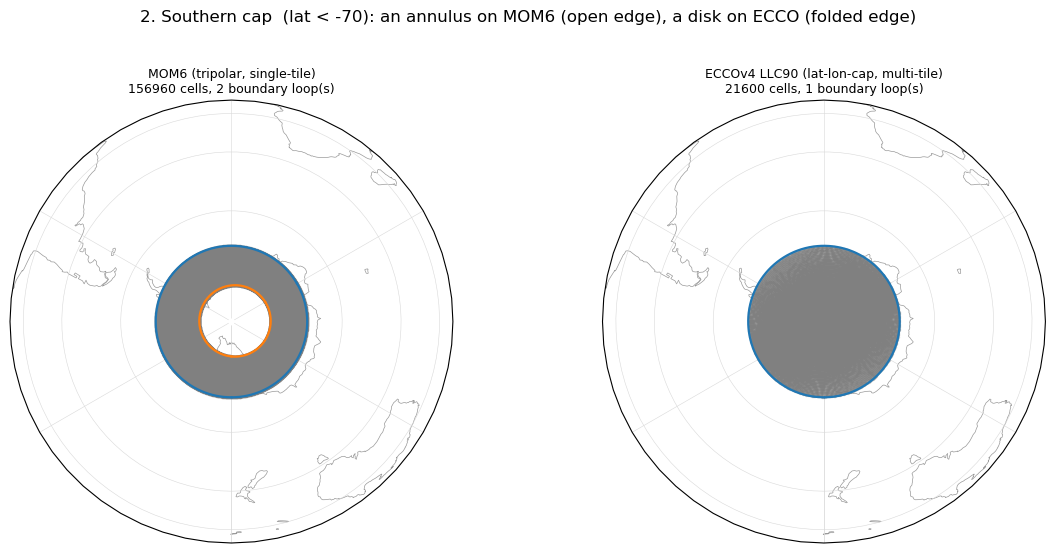

In [4]:
plot_case(lambda lo, la: la < -70., ccrs.Orthographic(0, -90),
          "2. Southern cap  (lat < -70): an annulus on MOM6 (open edge), a disk on ECCO (folded edge)")

### 3. A compact box that does **not** cross the antimeridian

A mid-latitude Atlantic box (`lon -50..-10, lat 20..50`) is the easy case: contiguous in index
space, one boundary loop.

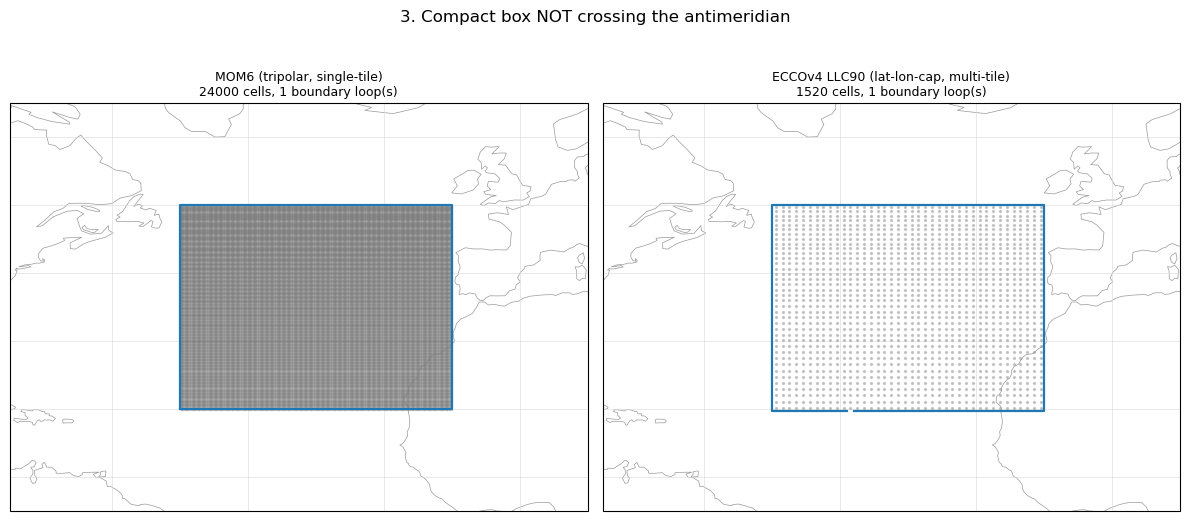

In [5]:
plot_case(box(-50, -10, 20, 50), ccrs.PlateCarree(),
          "3. Compact box NOT crossing the antimeridian", extent=[-75, 10, 5, 65])

### 4. A compact box that **does** cross the antimeridian

A Pacific box spanning `lon 150..-150` crosses &plusmn;180&deg;. On both grids it still traces as a
**single** boundary loop &mdash; on ECCO it also spans several tile seams. (The projection is
centred on 180&deg; so the box is contiguous in the figure.)

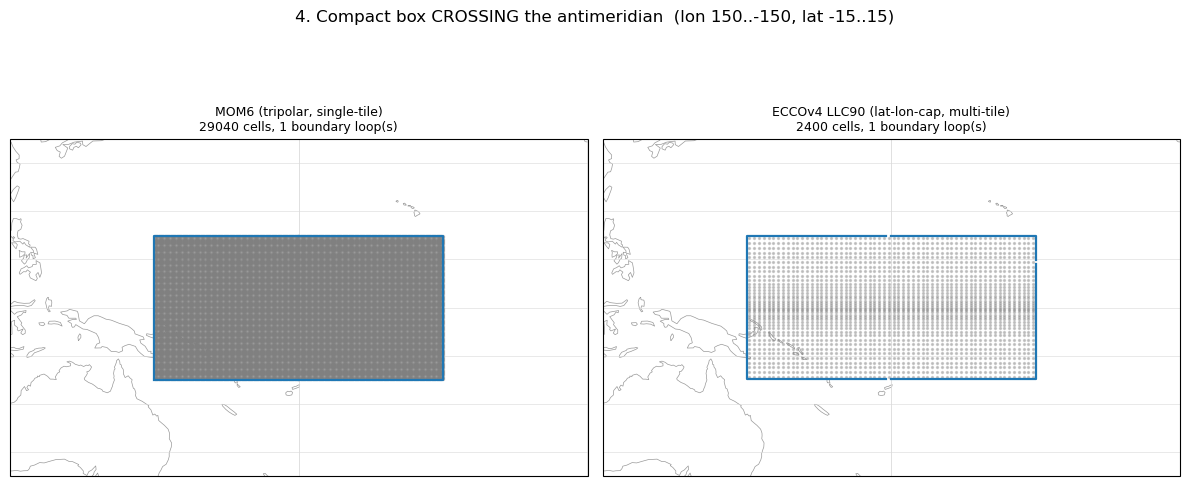

In [6]:
plot_case(lambda lo, la: ((lo >= 150) | (lo <= -150)) & (np.abs(la) <= 15),
          ccrs.PlateCarree(central_longitude=180),
          "4. Compact box CROSSING the antimeridian  (lon 150..-150, lat -15..15)",
          extent=[120, 240, -35, 35])

### 5. A zonal band that crosses **all** longitudes

A band `|lat| < 5` circles the entire globe, wrapping the periodic-*X* seam. Its boundary is
**two latitude circles** (the top and bottom edges), each closed all the way around &mdash; not
one loop with a spurious radial cut at the seam.

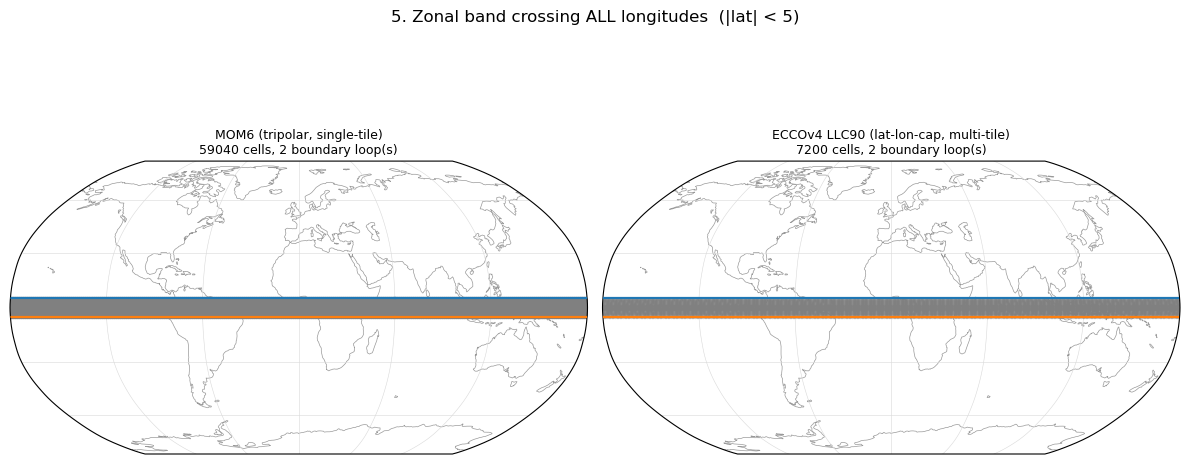

In [7]:
plot_case(lambda lo, la: np.abs(la) < 5., ccrs.Robinson(),
          "5. Zonal band crossing ALL longitudes  (|lat| < 5)")

### 6. Nested holes: a lake on an island inside an inland sea

Concentric boxes make a filled land ring, an inland sea (hole), an island (fill) in the sea, and
a lake (hole) on the island. `regionate` returns **four nested boundary loops**, one per
land/water interface (outer coast, inland-sea shore, island coast, lake shore).

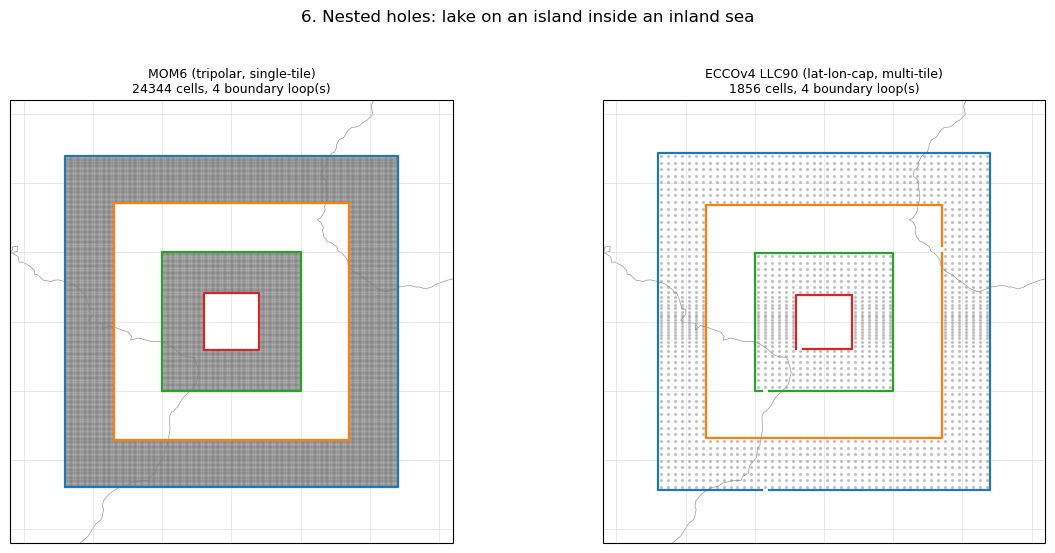

In [8]:
plot_case(nested(-30, 0), ccrs.PlateCarree(),
          "6. Nested holes: lake on an island inside an inland sea", extent=[-62, 2, -32, 32])

## Part 2 &mdash; boundary &rarr; mask

Given a lon/lat **polygon**, `GriddedRegion` rasterizes it to the enclosed cell mask (and traces
that mask's boundary, so we can show the round-trip). This direction currently uses `regionmask`,
which needs a **1D/2D** grid &mdash; so it runs on the single-tile MOM6 grid but not directly on
the multi-tile ECCO grid (the ECCO panel notes the supported workaround: build the mask per tile,
then trace it).

### 7. A polygon crossing the antimeridian

The antimeridian is handled by splitting the polygon at &plusmn;180&deg; into a MultiPolygon and
OR-ing the per-piece masks, so a box spanning `lon 150..-150` fills correctly.

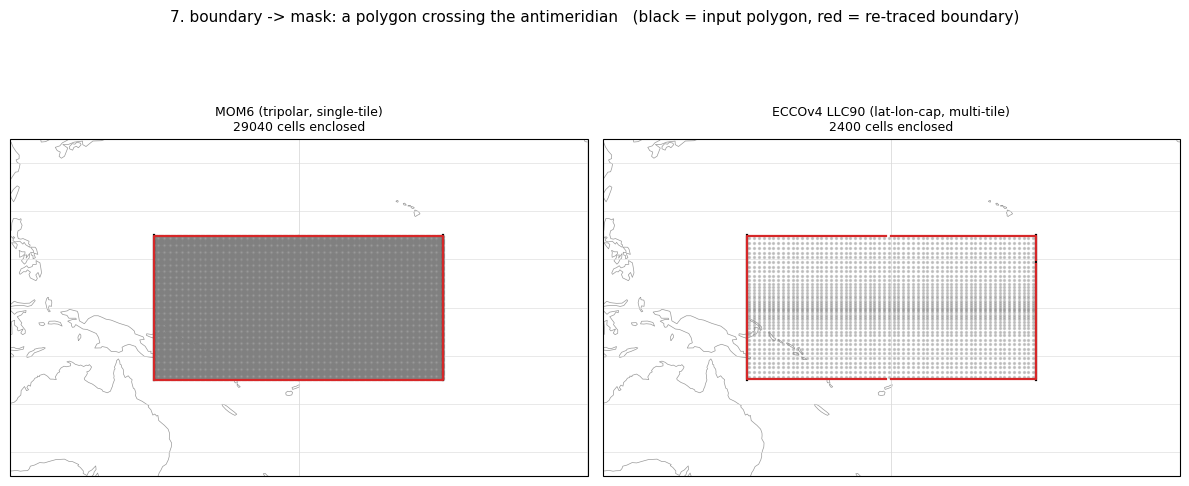

In [9]:
plot_b2m([150., 210., 210., 150.], [-15., -15., 15., 15.],
         ccrs.PlateCarree(central_longitude=180),
         "7. boundary -> mask: a polygon crossing the antimeridian",
         extent=[120, 240, -35, 35])

### 8. A diamond (diagonal edges &rarr; staircase)

A rotated square shows how a boundary that is not grid-aligned is rasterized: the enclosed mask
is filled, and its re-traced boundary is the **staircase** of cell corners that best approximates
the diagonal edges.

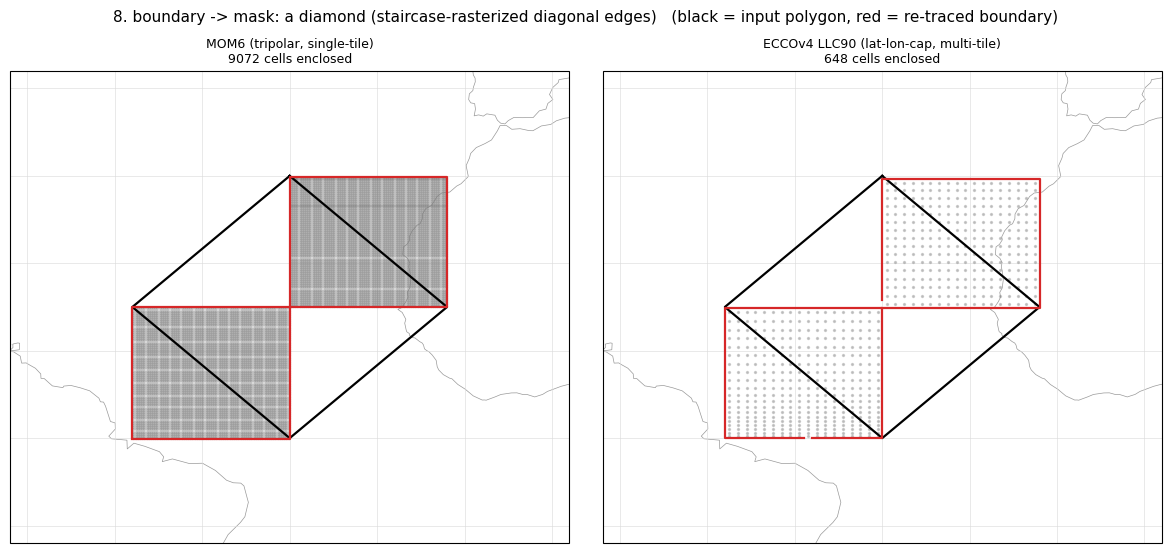

In [10]:
plot_b2m([-30., -12., -30., -48.], [30., 15., 0., 15.], ccrs.PlateCarree(),
         "8. boundary -> mask: a diamond (staircase-rasterized diagonal edges)",
         extent=[-62, 2, -12, 42])

## Notes on the corner cases

- **Poles.** A mask "contains a pole" only if the grid actually reaches it. The Arctic is ocean
  on both grids (case 1 &rarr; one disk). In the south the grids differ: MOM6's open southern
  edge makes the cap an annulus (case 2 &rarr; two loops), while LLC90 reaches &minus;90&deg;
  with a folded (self-coincident) southern boundary that regionate treats as interior, so the
  same cap is a single-loop disk on ECCO.
- **Seams are stitched, not cut.** Regions wrapping the antimeridian / periodic-*X* seam (cases 4,
  5, 7), the bipolar fold (case 1 on MOM6), or tile seams (cases 1, 4 on ECCO) trace into
  seam-consistent boundaries. A globe-circling band is two latitude circles (case 5), not one loop
  with a radial cut.
- **Multiple loops per connected region.** An annulus (case 2), a globe-circling strip (case 5), or
  a nested-hole region (case 6) is one connected region but has several boundary loops.
  `grid_boundaries_from_mask` returns them all; note that `MaskRegions` currently makes one
  `GriddedRegion` per loop, so budget closure is a property of the loop *set*
  ([regionate#23](https://github.com/hdrake/regionate/issues/23)).
- **boundary &rarr; mask** rasterization (`GriddedRegion` from a polygon) needs a 1D/2D grid; on a
  multi-tile grid, build the mask per tile (see `atlantic_basin_mask` in
  `load_example_ECCO_grid.py`) and then trace it with `MaskRegions`.